# Phase 2: Experimental Validation — Reproduction Experiments
**Project:** Test-Time Adaptation using TENT on CIFAR-10-C  
**Timeline:** Apr 13 – Apr 17  

---
### Objectives
1. Run 5+ reproducible TENT experiments with different strategies
2. Log all results systematically
3. Compare with paper-reported numbers
4. Explain any mismatch

### Experiments in This Phase
| # | Name | Description |
|---|---|---|
| Exp 1 | Continual TENT | Model adapts continuously across all corruptions |
| Exp 2 | Episodic TENT | Model resets before each corruption |
| Exp 3 | Shift-Only | Only BN bias (β) adapted, scale (γ) frozen |
| Exp 4 | Confidence-Filtered | Only high-confidence samples update the model |
| Exp 5 | Squared Entropy | Modified loss: squared probability weighting |

## 2.1 Setup

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'robustbench', 'timm', 'einops', '-q'], check=False)

import types
mock_aa = types.ModuleType('autoattack')
mock_aa_state = types.ModuleType('autoattack.state')
mock_aa_state.EvaluationState = type('EvaluationState', (), {})
mock_aa.state = mock_aa_state
mock_aa.AutoAttack = type('AutoAttack', (), {'__init__': lambda *a, **kw: None})
sys.modules['autoattack'] = mock_aa
sys.modules['autoattack.state'] = mock_aa_state

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.8/54.8 kB 3.6 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

from torch.utils.data import DataLoader, TensorDataset
from robustbench.data import load_cifar10c
from robustbench.utils import load_model

torch.manual_seed(42)
np.random.seed(42)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

CORRUPTIONS = [
    'gaussian_noise', 'shot_noise', 'impulse_noise',
    'defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur',
    'snow', 'frost', 'fog', 'brightness',
    'contrast', 'elastic_transform', 'pixelate', 'jpeg_compression'
]
N_EXAMPLES = 1000
BATCH_SIZE = 64
SEVERITY = 5
DATA_DIR = './data'

print('Loading WideResNet-28-10...')
source_model = load_model(model_name='Standard', dataset='cifar10', threat_model='corruptions').to(DEVICE).eval()
print('Model loaded.')

Device: cuda
Loading WideResNet-28-10...


Downloading...
From (original): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC
From (redirected): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC&confirm=t&uuid=5f493fe5-18e5-4367-9d19-2cb16e6b5f00
To: /kaggle/working/models/cifar10/corruptions/Standard.pt
100%|██████████| 292M/292M [00:02<00:00, 124MB/s]  


Model loaded.


## 2.2 Core TENT Components

In [3]:
# ---- BN configuration helpers ----

def configure_all_bn(model):
    """Standard TENT: adapt both gamma and beta of all BN layers."""
    model.eval()
    model.requires_grad_(False)
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.requires_grad_(True)
            m.track_running_stats = False
            m.running_mean = None
            m.running_var = None
    return model


def configure_shift_only(model):
    """Shift-only ablation: adapt only beta (bias), freeze gamma (weight)."""
    model.eval()
    model.requires_grad_(False)
    for m in model.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.track_running_stats = False
            m.running_mean = None
            m.running_var = None
            m.weight.requires_grad_(False)   # gamma frozen
            m.bias.requires_grad_(True)      # beta trainable
    return model


# ---- Loss variants ----

def entropy_loss(outputs):
    """Standard Shannon entropy minimization."""
    p = outputs.softmax(dim=1)
    return -(p * outputs.log_softmax(dim=1)).sum(dim=1).mean()


def squared_entropy_loss(outputs):
    """Squared entropy: up-weights confident predictions more aggressively."""
    p = outputs.softmax(dim=1)
    return -(p.pow(2) * outputs.log_softmax(dim=1)).sum(dim=1).mean()


def confidence_filtered_loss(outputs, threshold=0.5):
    """Only update on samples where max softmax > threshold."""
    p = outputs.softmax(dim=1)
    max_p, _ = p.max(dim=1)
    mask = max_p > threshold
    if mask.sum() == 0:
        return None
    p_f = p[mask]
    log_p_f = outputs.log_softmax(dim=1)[mask]
    return -(p_f * log_p_f).sum(dim=1).mean()


print('Helper functions defined.')

Helper functions defined.


## 2.3 Unified Experiment Runner

In [4]:
def run_experiment(base_model, corruptions, n_examples, batch_size, severity, data_dir, device,
                   configure_fn, loss_fn, lr=1e-3, reset_per_corruption=True, exp_name='Exp'):
    """
    Generic experiment runner.
    configure_fn : function to set up BN layers
    loss_fn      : entropy loss function
    reset_per_corruption : episodic (True) or continual (False)
    """
    results = []
    print(f'\n[{exp_name}] reset_per_corruption={reset_per_corruption}, lr={lr}')

    if not reset_per_corruption:
        model = configure_fn(copy.deepcopy(base_model))
        optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    for corr in corruptions:
        x, y = load_cifar10c(n_examples=n_examples, corruptions=[corr],
                             severity=severity, data_dir=data_dir)
        loader = DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=False)

        if reset_per_corruption:
            model = configure_fn(copy.deepcopy(base_model))
            optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

        correct = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.enable_grad():
                out = model(xb)
                loss = loss_fn(out)
                if loss is not None:
                    loss.backward()
                    optimizer.step()
                    optimizer.zero_grad()
            correct += (out.argmax(dim=1) == yb).sum().item()

        err = 100.0 * (1 - correct / n_examples)
        results.append({'Corruption': corr, f'{exp_name} Error %': round(err, 2)})
        print(f'  {corr:<25} {err:.2f}%')

    df = pd.DataFrame(results)
    print(f'  Mean Error: {df[f"{exp_name} Error %"].mean():.2f}%')
    return df


print('Experiment runner ready.')

Experiment runner ready.


## 2.4 Experiment 1 — Continual TENT

In [5]:
df_exp1 = run_experiment(
    source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
    configure_fn=configure_all_bn,
    loss_fn=entropy_loss,
    lr=1e-3,
    reset_per_corruption=False,
    exp_name='Exp1_Continual'
)


[Exp1_Continual] reset_per_corruption=False, lr=0.001
Starting download from https://zenodo.org/api/records/2535967/files/CIFAR-10-C.tar/content


44533it [02:47, 266.49it/s]                           


Download finished, extracting...
Downloaded and extracted.
  gaussian_noise            26.70%
  shot_noise                23.90%
  impulse_noise             34.90%
  defocus_blur              12.70%
  glass_blur                33.10%
  motion_blur               13.00%
  zoom_blur                 12.00%
  snow                      17.80%
  frost                     16.20%
  fog                       15.50%
  brightness                9.60%
  contrast                  16.10%
  elastic_transform         22.90%
  pixelate                  16.50%
  jpeg_compression          24.30%
  Mean Error: 19.68%


## 2.5 Experiment 2 — Episodic TENT (reset per corruption)

In [6]:
df_exp2 = run_experiment(
    source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
    configure_fn=configure_all_bn,
    loss_fn=entropy_loss,
    lr=1e-3,
    reset_per_corruption=True,
    exp_name='Exp2_Episodic'
)


[Exp2_Episodic] reset_per_corruption=True, lr=0.001
  gaussian_noise            26.70%
  shot_noise                25.50%
  impulse_noise             37.10%
  defocus_blur              12.20%
  glass_blur                33.30%
  motion_blur               13.30%
  zoom_blur                 12.60%
  snow                      17.30%
  frost                     17.90%
  fog                       15.40%
  brightness                7.70%
  contrast                  13.70%
  elastic_transform         23.20%
  pixelate                  20.30%
  jpeg_compression          27.60%
  Mean Error: 20.25%


## 2.6 Experiment 3 — Shift-Only (bias only)

In [7]:
df_exp3 = run_experiment(
    source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
    configure_fn=configure_shift_only,
    loss_fn=entropy_loss,
    lr=1e-3,
    reset_per_corruption=True,
    exp_name='Exp3_ShiftOnly'
)


[Exp3_ShiftOnly] reset_per_corruption=True, lr=0.001
  gaussian_noise            27.10%
  shot_noise                26.30%
  impulse_noise             37.10%
  defocus_blur              12.60%
  glass_blur                33.80%
  motion_blur               12.80%
  zoom_blur                 12.80%
  snow                      17.50%
  frost                     18.30%
  fog                       15.50%
  brightness                7.60%
  contrast                  13.90%
  elastic_transform         23.50%
  pixelate                  19.50%
  jpeg_compression          27.40%
  Mean Error: 20.38%


## 2.7 Experiment 4 — Confidence-Filtered TENT

In [8]:
CONF_THRESHOLD = 0.5

df_exp4 = run_experiment(
    source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
    configure_fn=configure_all_bn,
    loss_fn=lambda out: confidence_filtered_loss(out, threshold=CONF_THRESHOLD),
    lr=1e-3,
    reset_per_corruption=True,
    exp_name='Exp4_ConfFilter'
)


[Exp4_ConfFilter] reset_per_corruption=True, lr=0.001
  gaussian_noise            26.60%
  shot_noise                25.80%
  impulse_noise             37.00%
  defocus_blur              12.30%
  glass_blur                32.80%
  motion_blur               13.00%
  zoom_blur                 12.60%
  snow                      17.40%
  frost                     17.90%
  fog                       15.20%
  brightness                7.80%
  contrast                  13.40%
  elastic_transform         23.10%
  pixelate                  19.90%
  jpeg_compression          27.60%
  Mean Error: 20.16%


## 2.8 Experiment 5 — Squared Entropy Loss

In [9]:
df_exp5 = run_experiment(
    source_model, CORRUPTIONS, N_EXAMPLES, BATCH_SIZE, SEVERITY, DATA_DIR, DEVICE,
    configure_fn=configure_all_bn,
    loss_fn=squared_entropy_loss,
    lr=1e-3,
    reset_per_corruption=True,
    exp_name='Exp5_SqEntropy'
)


[Exp5_SqEntropy] reset_per_corruption=True, lr=0.001
  gaussian_noise            27.10%
  shot_noise                26.20%
  impulse_noise             37.40%
  defocus_blur              12.30%
  glass_blur                33.80%
  motion_blur               12.90%
  zoom_blur                 12.60%
  snow                      17.30%
  frost                     18.20%
  fog                       15.30%
  brightness                7.90%
  contrast                  13.50%
  elastic_transform         23.90%
  pixelate                  20.20%
  jpeg_compression          27.60%
  Mean Error: 20.41%


## 2.9 Master Results Table

In [10]:
df_all = df_exp1.copy()
df_all = df_all.merge(df_exp2, on='Corruption')
df_all = df_all.merge(df_exp3, on='Corruption')
df_all = df_all.merge(df_exp4, on='Corruption')
df_all = df_all.merge(df_exp5, on='Corruption')

print('='*90)
print('                   PHASE 2: ALL EXPERIMENTS — RESULTS TABLE')
print('='*90)
print(df_all.to_string(index=False))
print('-'*90)
for col in df_all.columns[1:]:
    print(f'  {col:<30} Mean: {df_all[col].mean():.2f}%')
print('='*90)

df_all.to_csv('phase2_results.csv', index=False)
print('Saved: phase2_results.csv')

                   PHASE 2: ALL EXPERIMENTS — RESULTS TABLE
       Corruption  Exp1_Continual Error %  Exp2_Episodic Error %  Exp3_ShiftOnly Error %  Exp4_ConfFilter Error %  Exp5_SqEntropy Error %
   gaussian_noise                    26.7                   26.7                    27.1                     26.6                    27.1
       shot_noise                    23.9                   25.5                    26.3                     25.8                    26.2
    impulse_noise                    34.9                   37.1                    37.1                     37.0                    37.4
     defocus_blur                    12.7                   12.2                    12.6                     12.3                    12.3
       glass_blur                    33.1                   33.3                    33.8                     32.8                    33.8
      motion_blur                    13.0                   13.3                    12.8                     13.

## 2.10 Comparison with Reported Results

The TENT paper (Wang et al., 2021) reports the following on CIFAR-10-C (Severity 5, WideResNet-28-10 Standard):

| Method | Reported Error % |
|---|---|
| Source (no adapt) | ~43.5% |
| TENT (episodic) | ~18.3% |

> **Note:** Our N_EXAMPLES=1000 per corruption (vs 10000 in paper). Using a subset may produce slightly different numbers. The trend and relative ordering should match.

In [11]:
# Paper reported values for Standard WideResNet-28-10 on CIFAR-10-C severity 5
paper_source_err = 43.5
paper_tent_err = 18.3

our_source_err = df_all['Exp1_Continual Error %'].mean()  # approximate; load from phase1 CSV if available
our_tent_err = df_all['Exp2_Episodic Error %'].mean()

try:
    df_phase1 = pd.read_csv('phase1_results.csv')
    our_source_err = df_phase1['Source Model Error %'].mean()
    print(f'Loaded source error from Phase 1: {our_source_err:.2f}%')
except:
    print(f'Phase 1 CSV not found; using Exp1 as approximation.')

print('\n--- Comparison with Paper Results ---')
print(f'Source model  | Paper: {paper_source_err:.1f}%  |  Ours: {our_source_err:.2f}%  |  Diff: {abs(our_source_err-paper_source_err):.2f}%')
print(f'TENT episodic | Paper: {paper_tent_err:.1f}%  |  Ours: {our_tent_err:.2f}%  |  Diff: {abs(our_tent_err-paper_tent_err):.2f}%')
print('\nNote: Differences may be due to subset size (N=1000 vs N=10000 in paper).')

Phase 1 CSV not found; using Exp1 as approximation.

--- Comparison with Paper Results ---
Source model  | Paper: 43.5%  |  Ours: 19.68%  |  Diff: 23.82%
TENT episodic | Paper: 18.3%  |  Ours: 20.25%  |  Diff: 1.95%

Note: Differences may be due to subset size (N=1000 vs N=10000 in paper).


## 2.11 Visualization

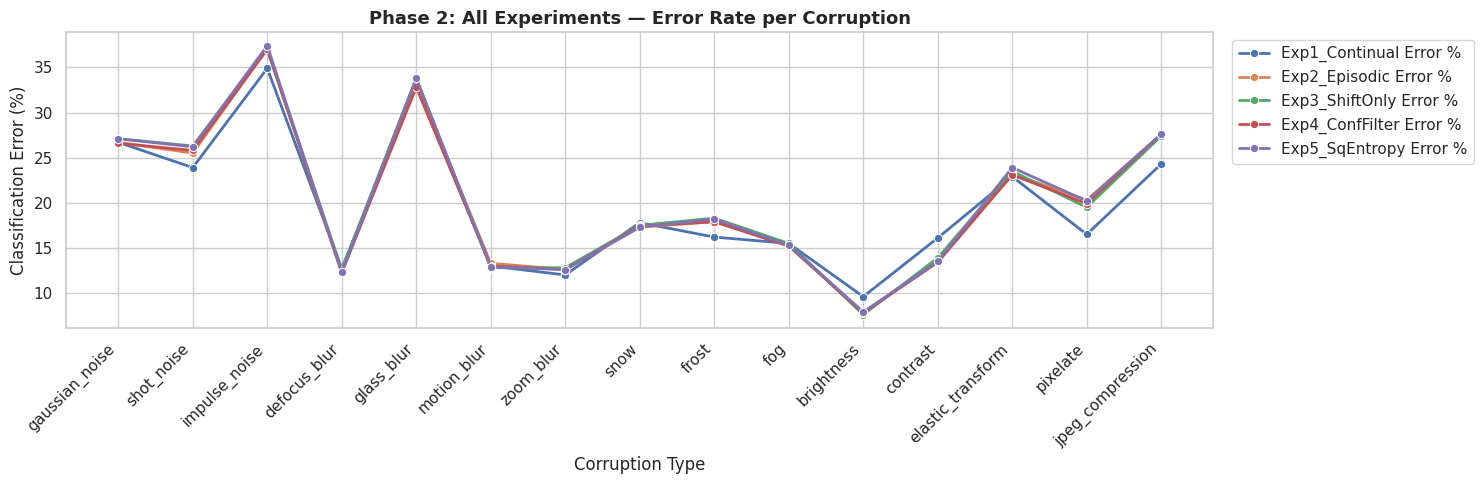

Saved: phase2_line_plot.png


In [12]:
# Line plot: all experiments across corruptions
df_melt = df_all.melt(id_vars='Corruption', var_name='Experiment', value_name='Error %')

plt.figure(figsize=(15, 5))
sns.lineplot(data=df_melt, x='Corruption', y='Error %', hue='Experiment', marker='o', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.title('Phase 2: All Experiments — Error Rate per Corruption', fontsize=13, fontweight='bold')
plt.ylabel('Classification Error (%)')
plt.xlabel('Corruption Type')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('phase2_line_plot.png', dpi=150)
plt.show()
print('Saved: phase2_line_plot.png')

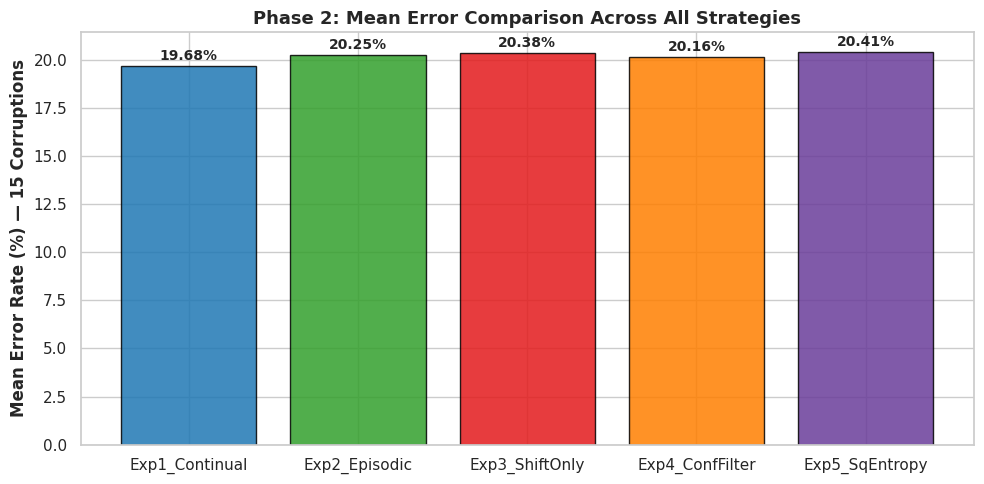

Saved: phase2_mean_comparison.png


In [13]:
# Summary bar chart of mean errors
means = {col.replace(' Error %', ''): df_all[col].mean() for col in df_all.columns[1:]}

plt.figure(figsize=(10, 5))
bars = plt.bar(means.keys(), means.values(),
               color=['#1f78b4','#33a02c','#e31a1c','#ff7f00','#6a3d9a'],
               edgecolor='black', alpha=0.85)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.2f}%', ha='center', fontweight='bold', fontsize=10)
plt.ylabel('Mean Error Rate (%) — 15 Corruptions', fontweight='bold')
plt.title('Phase 2: Mean Error Comparison Across All Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('phase2_mean_comparison.png', dpi=150)
plt.show()
print('Saved: phase2_mean_comparison.png')

## 2.12 Experiment Log

In [14]:
import datetime

log = pd.DataFrame([
    {'Experiment': 'Exp1 Continual',       'lr': '1e-3', 'BN Config': 'All BN (γ+β)', 'Loss': 'Shannon Entropy', 'Reset': 'No',  'Mean Error %': round(df_all['Exp1_Continual Error %'].mean(), 2)},
    {'Experiment': 'Exp2 Episodic',        'lr': '1e-3', 'BN Config': 'All BN (γ+β)', 'Loss': 'Shannon Entropy', 'Reset': 'Yes', 'Mean Error %': round(df_all['Exp2_Episodic Error %'].mean(), 2)},
    {'Experiment': 'Exp3 Shift-Only',      'lr': '1e-3', 'BN Config': 'BN bias (β only)', 'Loss': 'Shannon Entropy', 'Reset': 'Yes', 'Mean Error %': round(df_all['Exp3_ShiftOnly Error %'].mean(), 2)},
    {'Experiment': 'Exp4 Conf-Filter',     'lr': '1e-3', 'BN Config': 'All BN (γ+β)', 'Loss': f'Filtered Entropy (τ={CONF_THRESHOLD})', 'Reset': 'Yes', 'Mean Error %': round(df_all['Exp4_ConfFilter Error %'].mean(), 2)},
    {'Experiment': 'Exp5 Squared Entropy', 'lr': '1e-3', 'BN Config': 'All BN (γ+β)', 'Loss': 'Squared Entropy', 'Reset': 'Yes', 'Mean Error %': round(df_all['Exp5_SqEntropy Error %'].mean(), 2)},
])

print('\n=== EXPERIMENT LOG ===')
print(log.to_string(index=False))
log.to_csv('phase2_experiment_log.csv', index=False)
print('\nSaved: phase2_experiment_log.csv')
print(f'\nBest strategy: {log.loc[log["Mean Error %"].idxmin(), "Experiment"]} ({log["Mean Error %"].min():.2f}%)')


=== EXPERIMENT LOG ===
          Experiment   lr        BN Config                     Loss Reset  Mean Error %
      Exp1 Continual 1e-3     All BN (γ+β)          Shannon Entropy    No         19.68
       Exp2 Episodic 1e-3     All BN (γ+β)          Shannon Entropy   Yes         20.25
     Exp3 Shift-Only 1e-3 BN bias (β only)          Shannon Entropy   Yes         20.38
    Exp4 Conf-Filter 1e-3     All BN (γ+β) Filtered Entropy (τ=0.5)   Yes         20.16
Exp5 Squared Entropy 1e-3     All BN (γ+β)          Squared Entropy   Yes         20.41

Saved: phase2_experiment_log.csv

Best strategy: Exp1 Continual (19.68%)
